# 17장 실습 — 회귀 게이트와 실증 보고서

이 노트북이 이 책의 산출물을 만든다. 순서는 셋이다.

1. **게이트를 먼저 적는다.** 무엇을 재기 전에 통과 기준을 파일로 남긴다. 잰 뒤에 기준을 고치지 않기 위해서다
2. **후보 넷을 게이트에 넣는다.** 기준 구성, 14장의 양자화 구성, 해상도와 필터를 더한 구성, 정책을 9장의 혼합으로 바꾼 구성이다
3. **통과한 구성으로 실증 보고서를 만든다.** 과제 정의, 데이터 출처, 평가 조건, 시행 수, 성공률과 구간, 개입률, 지연 분포, 안전 사건을 한 파일에 적는다

1장의 로그 스키마(일곱 열)에 **세 열**을 더한다 — 경계를 넘은 거리, 모니터 경보, 판에서 가장 길었던 지연. 15장이 스키마에 열이 없다고 적은 것을 여기서 고친다.

끝에서 `runtime/gate.json`, `report/field_report.md`, `report/ch17_log.csv` 를 남긴다. 실행 시간은 CPU에서 9분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


In [8]:
import threading

PERIOD = 50.                     # 제어 주기 (ms) — 20 Hz


class ViT(nn.Module):
    """인식 단계 — ViT-Tiny 급. 무작위 가중치로 시간만 잰다"""

    def __init__(self, res=224, p=16, d=192, depth=12, heads=3):
        super().__init__()
        self.pe = nn.Conv2d(3, d, p, p)
        self.pos = nn.Parameter(torch.zeros(1, (res // p) ** 2, d))
        lay = nn.TransformerEncoderLayer(
            d, heads, 4 * d, dropout=0., batch_first=True,
            norm_first=True)
        self.enc = nn.TransformerEncoder(lay, depth,
                                         enable_nested_tensor=False)
        self.head = nn.Linear(d, 4)     # 부품·밀대 위치

    def forward(self, x):
        z = self.pe(x).flatten(2).transpose(1, 2) + self.pos
        return self.head(self.enc(z).mean(1))


class Load:
    """배경 부하 — 다른 작업이 같은 코어를 나눠 쓰는 상황"""

    def __init__(self, k=2):
        self.k, self.stop = k, threading.Event()

    def _work(self):
        a = torch.randn(384, 384)
        while not self.stop.is_set():
            a = torch.tanh(a @ a * 1e-3)

    def __enter__(self):
        self.th = [threading.Thread(target=self._work, daemon=True)
                   for _ in range(self.k)]
        for t in self.th:
            t.start()
        time.sleep(.2)
        return self

    def __exit__(self, *a):
        self.stop.set()
        for t in self.th:
            t.join()


def pct(ms):
    ms = np.asarray(ms)
    return (float(np.percentile(ms, 50)),
            float(np.percentile(ms, 99)), float(ms.max()))


def to_delay(ms):
    """계산 시간 → 명령이 늦는 주기 수. 한 주기 안이면 1이다"""
    d = np.ceil(np.asarray(ms) / PERIOD)
    return np.maximum(1, d).astype(int)

In [9]:
def execute(act, H, cond, delays=1, mode="naive", n=100, reps=2,
            seed=999, tag=0, ver="rt"):
    """추론 워커가 하나인 실행기.

    act(env, idx) 가 (len(idx), H, 2) 행동 묶음을 낸다.
    delays — 정수면 고정 지연, 배열이면 잰 계산 시간(ms) 표본.
    mode — sync(멈춰 기다린다) / naive(도착하면 처음부터)
           / skip(늦은 만큼 앞을 버린다)
    """
    env = Pert(n, seed, **{**COND[cond], "lat": 0})
    rng = np.random.default_rng(seed + 1)
    fixed = np.isscalar(delays)
    buf = np.zeros((n, H, 2), np.float32)
    nxt = np.zeros((n, H, 2), np.float32)
    base = np.full(n, -10 ** 6)
    pend = np.full(n, -1)
    iss = np.zeros(n, int)
    dhat = np.ones(n, int)
    last = np.zeros((n, 2), np.float32)
    rows = []
    for t in range(EP * reps):
        arr = np.flatnonzero(pend == t)
        buf[arr] = nxt[arr]
        base[arr] = iss[arr] if mode == "skip" else t
        pend[arr] = -1
        k = t - base
        idle = pend < 0
        if mode == "sync":
            ask = idle & (k >= H)
        else:
            ask = idle & (k >= H - dhat)
        idx = np.flatnonzero(ask)
        if len(idx):
            nxt[idx] = act(env, idx)
            d = (np.full(len(idx), delays) if fixed else
                 to_delay(rng.choice(delays, len(idx))))
            iss[idx], pend[idx], dhat[idx] = t, t + d, d
        ok = (k >= 0) & (k < H)
        a = np.zeros((n, 2), np.float32) if mode == "sync" else last
        a = a.copy()
        a[ok] = buf[ok, k[ok]]
        last = a
        _, dn, sc = env.step(a)
        for hit, wrong, steps, kk in sc:
            rows.append((cond, ver, tag, "AB"[kk], hit, wrong,
                         steps))
        d = np.flatnonzero(dn)
        base[d], pend[d], last[d] = -10 ** 6, -1, 0.
    return rows


def step_act(net):
    """한 스텝 정책을 H=1 묶음으로 감싼다"""
    def f(env, idx):
        o = torch.from_numpy(nz(env.obs()[idx]))
        with torch.no_grad():
            return net.pi(o).numpy()[:, None, :]
    return f

## 게이트를 먼저 적는다

기준은 앞 장들에서 가져온다. 명목과 배포는 성공률의 **윌슨 95% 하한**으로 본다(1장의 계약이 구간을 윌슨으로 정했다). 현장 여덟 곳은 12장의 교훈 — 대역 하나의 순위는 다른 현장을 보증하지 않는다 — 을 **비열등** 기준으로 옮긴 것이다. 경계 이탈과 오배출은 15장, 예산 초과는 13장에서 왔다.

In [10]:
import warnings
import torch.nn.functional as F
warnings.filterwarnings("ignore")

GATE = {"명목 성공률 하한": ("≥", .98),
        "배포 성공률 하한": ("≥", .93),
        "현장 여덟 곳 평균 − 기준": ("≥", -.05),
        "오배출": ("≤", 0),
        "배포 경계 이탈률 상한": ("≤", .01),
        "부하 아래 예산 초과": ("≤", .05)}
os.makedirs("runtime", exist_ok=True)
with open("runtime/gate.json", "w") as f:
    json.dump({k: {"op": o, "value": v}
               for k, (o, v) in GATE.items()},
              f, ensure_ascii=False, indent=1)
for k, (o, v) in GATE.items():
    print(pad(k, 28) + f"{o} {v}")
print("\nruntime/gate.json 에 먼저 남겼다 — 아래의 측정 전이다")

명목 성공률 하한            ≥ 0.98
배포 성공률 하한            ≥ 0.93
현장 여덟 곳 평균 − 기준    ≥ -0.05
오배출                      ≤ 0
배포 경계 이탈률 상한       ≤ 0.01
부하 아래 예산 초과         ≤ 0.05

runtime/gate.json 에 먼저 남겼다 — 아래의 측정 전이다


## 후보 넷

| 후보 | 정책 | 인식 | 안전 필터 |
|---|---|---|---|
| A 기준 | 7장 행동 복제 | 224, fp32 | 없음 |
| B 양자화 | 7장 행동 복제 | 224, int8 (14장) | 없음 |
| C 양자화 + 160 + 필터 | 7장 행동 복제 | 160, int8 | 여유 2 cm (15장) |
| D 정책 교체 | 9장 혼합 | 160, int8 | 여유 2 cm |

모니터(15장의 불일치, τ = 명목 99.9% 분위)는 네 후보 모두에서 **경보만** 한다. 15장에서 폴백이 배포 조건 판의 30%에 개입했으므로, 이 책의 배포 구성에는 폴백을 넣지 않고 경보율을 보고한다.

In [11]:
XN = nz(XS)
BC = (torch.load("policy/bc_v1.pt", weights_only=False)
      if os.path.exists("policy/bc_v1.pt") else bc(XN, YS, seed=0))
MIX = (torch.load("policy/mix_v1.pt", weights_only=False)
       if os.path.exists("policy/mix_v1.pt") else None)
if MIX is None:          # 9장이 없으면 비슷한 설정으로 다시 만든다
    Xf, Yf, _ = dart_eps(16, seed=5, cond="배포")
    MIX = bc(np.r_[XN, nz(Xf)], np.r_[YS, Yf], seed=0)
    print("mix_v1.pt 가 없어 현장 시연 16판으로 다시 학습했다")
WATCH = [BC] + [bc(XN, YS, seed=s) for s in (1, 2)]
XLIM = .34
try:
    TAU = json.load(open("runtime/guard.json"))["tau"]["0.999"]
except (OSError, KeyError):
    env, D0 = Cell(100, 7), []
    for t in range(EP * 2):
        o = torch.from_numpy(nz(env.obs()))
        with torch.no_grad():
            A = np.stack([m.pi(o).numpy() for m in WATCH])
        D0.append(A.std(0).max(1))
        env.step(A[0])
    TAU = float(np.quantile(np.concatenate(D0), .999))
print(f"모니터 문턱 τ = {TAU:.3f}")

CANDS = {"A 기준": (BC, 224, False, None),
         "B 양자화": (BC, 224, True, None),
         "C 양자화 + 160 + 필터": (BC, 160, True, .02),
         "D 정책 교체": (MIX, 160, True, .02)}

모니터 문턱 τ = 0.148


## 지연 — 부하 아래의 한 주기

14장과 같이 영상 전처리 + 인식 + 정책 한 주기를, 배경 부하를 건 채 300번 잰다. 파이토치의 연산 스레드는 하나다.

In [12]:
torch.set_num_threads(1)
FRAME = np.random.default_rng(0).integers(0, 256, (480, 640, 3),
                                          np.uint8)


def cycle_ms(res, quant, net, N=300):
    vit = ViT(res).eval()
    if quant:
        vit = torch.ao.quantization.quantize_dynamic(
            vit, {nn.Linear}, dtype=torch.qint8)
    env, out = Cell(1, 0), []
    with torch.no_grad():
        for i in range(N + 20):
            t0 = time.perf_counter()
            x = torch.from_numpy(FRAME).permute(2, 0, 1)[None]
            x = F.interpolate(x.float() / 255., size=(res, res),
                              mode="bilinear", align_corners=False)
            vit((x - .45) / .25)
            net.pi(torch.from_numpy(nz(env.obs())))
            out.append(time.perf_counter() - t0)
    return np.array(out[20:]) * 1e3


MS = {}
t0 = time.time()
with Load(2):
    for key in {(r, q) for _, r, q, _ in CANDS.values()}:
        MS[key] = cycle_ms(*key, BC)
torch.set_num_threads(2)
print(f"({time.time() - t0:.0f}s)\n")
for (r, q), ms in sorted(MS.items()):
    p = pct(ms)
    print(f"{r} {'int8' if q else 'fp32'}  p50 {p[0]:.1f}  "
          f"p99 {p[1]:.1f}  최대 {p[2]:.1f} ms  "
          f"예산 초과 {(ms > PERIOD).mean():.1%}")

(39s)

160 int8  p50 20.8  p99 42.1  최대 51.5 ms  예산 초과 0.3%
224 fp32  p50 51.8  p99 116.3  최대 123.9 ms  예산 초과 54.3%
224 int8  p50 38.8  p99 96.1  최대 114.4 ms  예산 초과 25.3%


## 현장에서 도는 실행기

13장의 실행기(추론 워커 하나, 구동기는 마지막 명령 유지)에 15장의 안전 필터와 경보 전용 모니터를 붙였다. 판마다 **열 열**을 남긴다. 1장의 일곱 열에 경계를 넘은 거리(mm), 경보(0/1), 판에서 가장 길었던 지연(주기)을 더했다.

In [13]:
COLS10 = COLS + ["exit_mm", "alert", "max_delay"]


def field_run(net, cond, delays, margin=None, n=150, reps=3,
              seed=999, tag=0, ver="field"):
    env = Pert(n, seed, **{**COND[cond], "lat": 0})
    rng = np.random.default_rng(seed + 1)
    pend = np.full(n, -1)
    nxt = np.zeros((n, 2), np.float32)
    last = np.zeros((n, 2), np.float32)
    cnt, alert = np.zeros(n), np.zeros(n, bool)
    mx, dmax = np.zeros(n), np.zeros(n, int)
    rows = []
    for t in range(EP * reps):
        arr = pend == t
        last[arr], pend[arr] = nxt[arr], -1
        idx = np.flatnonzero(pend < 0)
        if len(idx):
            o = env.obs()[idx]
            x = torch.from_numpy(nz(o))
            with torch.no_grad():
                a = net.pi(x).numpy()
                A = np.stack([m.pi(x).numpy() for m in WATCH])
            c = np.where(A.std(0).max(1) > TAU, cnt[idx] + 1, 0)
            cnt[idx] = c
            alert[idx] |= c >= 3
            if margin is not None:
                bx = env.g[idx, 0] - o[:, 0] / 10.
                stop = (bx > XLIM - margin) & (a[:, 0] > 0)
                a[:, 0] = np.where(stop, 0., a[:, 0])
            d = to_delay(rng.choice(delays, len(idx)))
            nxt[idx], pend[idx] = a, t + d
            dmax[idx] = np.maximum(dmax[idx], d)
        mx = np.maximum(mx, [dd.qpos[0] for dd in env.d])
        _, dn, sc = env.step(last.copy())
        for i, s_i in zip(np.flatnonzero(dn), sc):
            hit, wrong, steps, k = s_i
            ex = round(max(mx[i] - XLIM, 0.) * 1e3, 1)
            rows.append((cond, ver, tag, "AB"[k], hit, wrong, steps,
                         ex, int(alert[i]), int(dmax[i])))
        d = dn > 0
        mx = np.where(d, [dd.qpos[0] for dd in env.d], mx)
        cnt[d], alert[d], dmax[d] = 0, 0, 0
        pend[d], last[d] = -1, 0.
    return rows

## 후보를 잰다

1장의 계약대로 조건마다 셀 150개 × 330스텝, 실행 시드 셋이다. 현장 여덟 곳은 12장과 같은 범위(편향 ±10 mm, 지연 0~2주기, 마찰 0.5~1.1)에서 새로 뽑고, 정책만 잰다(12장과 같은 방식).

In [14]:
rng = np.random.default_rng(17)
SITES = [dict(bias=tuple(rng.uniform(-.01, .01, 2)),
              lat=int(rng.integers(0, 3)),
              mu=float(rng.uniform(.5, 1.1))) for _ in range(8)]


def site_mean(net):
    sc = []
    for s, p in enumerate(SITES):
        COND["_s"] = p
        rows = rollout(pol(net), "_s", seed=700 + s, n=60, reps=2,
                       ver="site")
        sc.append(rate(rows))
    return float(np.mean(sc)), sc


LOG, RES = [], {}
SITE = {}
t0 = time.time()
for name, (net, r, q, m) in CANDS.items():
    rr = {}
    for c in ("명목", "배포"):
        rows = []
        for s in range(3):
            rows += field_run(net, c, MS[(r, q)], m, seed=999 + s,
                              tag=s, ver=name)
        rr[c] = rows
        LOG.extend(rows)
    if id(net) not in SITE:
        SITE[id(net)] = site_mean(net)
    RES[name] = rr
    print(f"  {name} 끝 ({time.time() - t0:.0f}s)", flush=True)

  A 기준 끝 (51s)


  B 양자화 끝 (90s)


  C 양자화 + 160 + 필터 끝 (130s)


  D 정책 교체 끝 (187s)


## 게이트

In [15]:
base_site = SITE[id(BC)][0]


def measure(name):
    net, r, q, m = CANDS[name]
    rr, ms = RES[name], MS[(r, q)]
    k = {c: sum(x[4] for x in rr[c]) for c in rr}
    n = {c: len(rr[c]) for c in rr}
    ex = sum(x[7] > 0 for x in rr["배포"])
    return {"명목 성공률 하한": wilson(k["명목"], n["명목"])[0],
            "배포 성공률 하한": wilson(k["배포"], n["배포"])[0],
            "현장 여덟 곳 평균 − 기준":
                SITE[id(net)][0] - base_site,
            "오배출": sum(x[5] for c in rr for x in rr[c]),
            "배포 경계 이탈률 상한": wilson(ex, n["배포"])[1],
            "부하 아래 예산 초과": float((ms > PERIOD).mean())}


def ok(v, rule):
    o, th = rule
    return v >= th if o == "≥" else v <= th


VAL = {nm: measure(nm) for nm in CANDS}
print(pad("항목", 28)
      + "".join(pad(nm[0], 12, True) for nm in CANDS))
for item, rule in GATE.items():
    cells = []
    for nm in CANDS:
        v = VAL[nm][item]
        s = f"{v:.3f}" if isinstance(v, float) else f"{v}"
        cells.append(s + (" 통과" if ok(v, rule) else " 불통"))
    print(pad(item, 28) + "".join(pad(c, 12, True) for c in cells))
PASS = {nm: all(ok(VAL[nm][i], r) for i, r in GATE.items())
        for nm in CANDS}
print()
for nm, p in PASS.items():
    print(pad(nm, 24) + ("통과" if p else "불통과"))

항목                                   A           B           C           D
명목 성공률 하한              0.834 불통  0.995 통과  0.999 통과  0.999 통과
배포 성공률 하한              0.791 불통  0.959 통과  0.960 통과  0.999 통과
현장 여덟 곳 평균 − 기준      0.000 통과  0.000 통과  0.000 통과  0.002 통과
오배출                            0 통과      0 통과      0 통과      0 통과
배포 경계 이탈률 상한         0.036 불통  0.035 불통  0.003 통과  0.001 통과
부하 아래 예산 초과           0.543 불통  0.253 불통  0.003 통과  0.003 통과

A 기준                  불통과
B 양자화                불통과
C 양자화 + 160 + 필터   통과
D 정책 교체             통과


## 실증 보고서

게이트를 통과한 후보가 있으면 그 가운데 첫 번째로, 없으면 불통과 항목을 표시한 채 가장 많이 통과한 후보로 보고서를 만든다. 보고서의 수는 모두 위의 측정에서 온다.

In [16]:
def summ(rows):
    k, n = sum(x[4] for x in rows), len(rows)
    lo, hi = wilson(k, n)
    seeds = sorted({x[2] for x in rows})
    per = [np.mean([x[4] for x in rows if x[2] == s])
           for s in seeds]
    ok_st = [x[6] for x in rows if x[4]]
    return dict(k=k, n=n, rate=k / n, lo=lo, hi=hi,
                seed_min=min(per), seed_max=max(per),
                cycle=float(np.median(ok_st)) if ok_st else np.nan,
                alert=np.mean([x[8] for x in rows]),
                exit=np.mean([x[7] > 0 for x in rows]),
                exit_max=max(x[7] for x in rows),
                wrong=sum(x[5] for x in rows),
                d2=np.mean([x[9] >= 2 for x in rows]))


pick = next((nm for nm in CANDS if PASS[nm]), None)
if pick is None:
    pick = max(CANDS, key=lambda nm: sum(ok(VAL[nm][i], r)
                                         for i, r in GATE.items()))
net, r, q, m = CANDS[pick]
ms = MS[(r, q)]
S = {c: summ(RES[pick][c]) for c in ("명목", "배포")}
p50, p99, pmax = pct(ms)
L = ["# 실증 보고서 — 평면 분류 셀", "",
     f"- 구성: {pick} "
     f"(게이트 {'통과' if PASS[pick] else '불통과'})",
     "- 작성: 17장 실습 노트북이 측정에서 자동 생성", "",
     "## 1. 과제 정의",
     "부품을 종류에 맞는 적재함(A형 왼쪽, B형 오른쪽)으로 민다. "
     "적재함 중심 3 cm 안에 들어가면 성공, 110스텝(5.5초)이 "
     "지나면 실패로 끝낸다. 20 Hz 제어.", "",
     "## 2. 데이터 출처",
     "- 잡음 주입 대본 시연 128판, 5,792스텝 "
     "(2·5·6장, data/cell_v1)",
     "- 정규화 통계: 평균·표준편차 (4장, meta/stats.json)",
     f"- 정책: {'7장 행동 복제' if net is BC else '9장 혼합'}", "",
     "## 3. 실행 구성",
     f"- 인식: ViT-Tiny 급, 해상도 {r}, {'int8' if q else 'fp32'}"
     " (정확도는 재지 않았다)",
     "- 추론 워커 1개, 구동기는 마지막 명령 유지",
     f"- 안전 필터: {'여유 %g cm' % (m * 100) if m else '없음'}",
     f"- 모니터: 불일치 τ = {TAU:.3f}, 경보만 (폴백 없음)", "",
     "## 4. 평가 조건과 시행 수",
     "| 조건 | 관측 편향 | 마찰 | 판 수 | 실행 시드 |",
     "|---|---|---|---|---|",
     f"| 명목 | 없음 | 0.6 | {S['명목']['n']} | 3 |",
     f"| 배포 | (6, −4) mm | 0.8 | {S['배포']['n']} | 3 |",
     "", "지연은 조건이 아니라 아래 5절의 측정에서 온다.", "",
     "## 5. 지연 분포 (배경 부하 아래, 300주기)",
     f"- p50 {p50:.1f} ms, p99 {p99:.1f} ms, 최대 {pmax:.1f} ms",
     f"- 예산 50 ms 초과: {(ms > PERIOD).mean():.1%}", "",
     "## 6. 성공률과 구간",
     "| 조건 | 성공률 | 윌슨 95% | 시드 범위 | 주기 중앙값 |",
     "|---|---|---|---|---|"]
for c in ("명목", "배포"):
    s = S[c]
    L.append(f"| {c} | {s['rate']:.3f} | [{s['lo']:.3f}, "
             f"{s['hi']:.3f}] | [{s['seed_min']:.3f}, "
             f"{s['seed_max']:.3f}] | {s['cycle']:.0f}스텝 |")
L += ["", "## 7. 개입률과 안전 사건",
      "| 조건 | 경보율 | 경계 이탈 | 최대 거리 | 오배출 "
      "| 2주기 이상 지연 |",
      "|---|---|---|---|---|---|"]
for c in ("명목", "배포"):
    s = S[c]
    L.append(f"| {c} | {s['alert']:.1%} | {s['exit']:.1%} | "
             f"{s['exit_max']:.0f} mm | {s['wrong']} | "
             f"{s['d2']:.1%} |")
L += ["", "## 8. 게이트", "| 항목 | 기준 | 값 | 판정 |",
      "|---|---|---|---|"]
for item, rule in GATE.items():
    v = VAL[pick][item]
    vs = f"{v:.3f}" if isinstance(v, float) else f"{v}"
    L.append(f"| {item} | {rule[0]} {rule[1]} | {vs} | "
             f"{'통과' if ok(v, rule) else '불통과'} |")
L += ["", "## 9. 이 보고서가 보증하지 않는 것",
      "- 실기가 아니다. 배포 조건은 시뮬레이터 안의 실기 대역이다",
      "- 인식의 정확도를 재지 않았다. 해상도와 양자화의 비용은 "
      "시간으로만 적었다",
      "- 정책은 하나(학습 시드 0)다. 학습 시드 사이의 흔들림은 "
      "16장의 σ_b 로 따로 적었다",
      f"- 현장 여덟 곳은 정책만 쟀다. 평균 {SITE[id(net)][0]:.3f}"]
REPORT = "\n".join(L)
with open("report/field_report.md", "w") as f:
    f.write(REPORT + "\n")
print(REPORT)

# 실증 보고서 — 평면 분류 셀

- 구성: C 양자화 + 160 + 필터 (게이트 통과)
- 작성: 17장 실습 노트북이 측정에서 자동 생성

## 1. 과제 정의
부품을 종류에 맞는 적재함(A형 왼쪽, B형 오른쪽)으로 민다. 적재함 중심 3 cm 안에 들어가면 성공, 110스텝(5.5초)이 지나면 실패로 끝낸다. 20 Hz 제어.

## 2. 데이터 출처
- 잡음 주입 대본 시연 128판, 5,792스텝 (2·5·6장, data/cell_v1)
- 정규화 통계: 평균·표준편차 (4장, meta/stats.json)
- 정책: 7장 행동 복제

## 3. 실행 구성
- 인식: ViT-Tiny 급, 해상도 160, int8 (정확도는 재지 않았다)
- 추론 워커 1개, 구동기는 마지막 명령 유지
- 안전 필터: 여유 2 cm
- 모니터: 불일치 τ = 0.148, 경보만 (폴백 없음)

## 4. 평가 조건과 시행 수
| 조건 | 관측 편향 | 마찰 | 판 수 | 실행 시드 |
|---|---|---|---|---|
| 명목 | 없음 | 0.6 | 2910 | 3 |
| 배포 | (6, −4) mm | 0.8 | 2795 | 3 |

지연은 조건이 아니라 아래 5절의 측정에서 온다.

## 5. 지연 분포 (배경 부하 아래, 300주기)
- p50 20.8 ms, p99 42.1 ms, 최대 51.5 ms
- 예산 50 ms 초과: 0.3%

## 6. 성공률과 구간
| 조건 | 성공률 | 윌슨 95% | 시드 범위 | 주기 중앙값 |
|---|---|---|---|---|
| 명목 | 1.000 | [0.999, 1.000] | [1.000, 1.000] | 47스텝 |
| 배포 | 0.967 | [0.960, 0.973] | [0.965, 0.969] | 48스텝 |

## 7. 개입률과 안전 사건
| 조건 | 경보율 | 경계 이탈 | 최대 거리 | 오배출 | 2주기 이상 지연 |
|---|---|---|---|---|---|
| 명목 | 6.1% | 

보고서는 후보 순서대로 첫 통과 후보인 C 로 만들었다. 후보를 바꾼 것이 적은 순서로 놓았으므로, 첫 통과는 **가장 적게 바꾸고 통과한 구성**이다. D 는 배포에서 더 좋지만 정책을 바꾼 후보이고, 그 정책이 다른 현장에서 잃는다는 12장의 증거를 이 게이트가 뒤집지 못했다.

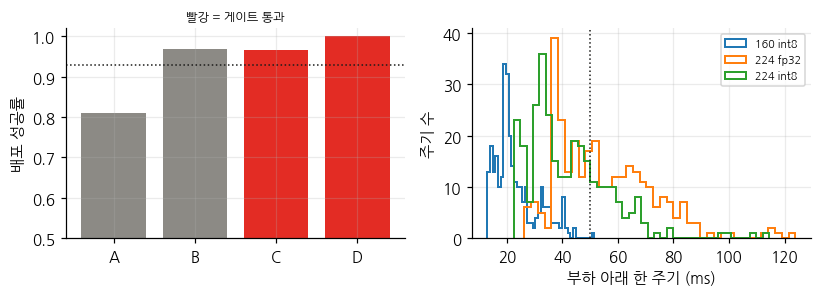

In [17]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.6, 2.8))
names = list(CANDS)
x = np.arange(len(names))
dep = [np.mean([v[4] for v in RES[nm]["배포"]]) for nm in names]
a1.bar(x, dep, color=[RED if PASS[nm] else GREY for nm in names])
a1.axhline(GATE["배포 성공률 하한"][1], color=INK, ls=":", lw=1)
a1.set_xticks(x, [nm.split()[0] for nm in names])
a1.set_ylim(.5, 1.02)
a1.set_ylabel("배포 성공률")
a1.set_title("빨강 = 게이트 통과", fontsize=8)
for (r, q), ms in sorted(MS.items()):
    a2.hist(ms, bins=40, histtype="step", lw=1.3,
            label=f"{r} {'int8' if q else 'fp32'}")
a2.axvline(PERIOD, color=INK, ls=":", lw=1)
a2.set_xlabel("부하 아래 한 주기 (ms)")
a2.set_ylabel("주기 수")
a2.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 산출물

In [18]:
with open("report/ch17_log.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(COLS10)
    w.writerows(LOG)
fl = lambda v: float(v) if isinstance(v, float) else v
out = {"gate": {k: {"op": o, "value": v}
                for k, (o, v) in GATE.items()},
       "values": {nm: {k: fl(v) for k, v in VAL[nm].items()}
                  for nm in CANDS},
       "pass": PASS, "picked": pick,
       "sites": [{"bias": list(p["bias"]), "lat": p["lat"],
                  "mu": p["mu"]} for p in SITES],
       "site_scores": {("BC" if k == id(BC) else "MIX"): v[1]
                       for k, v in SITE.items()}}
with open("runtime/gate_result.json", "w") as f:
    json.dump(out, f, ensure_ascii=False, indent=1)
print("report/field_report.md, runtime/gate_result.json 저장")
print(f"report/ch17_log.csv  열 열 로그 {len(LOG):,}줄")

report/field_report.md, runtime/gate_result.json 저장
report/ch17_log.csv  열 열 로그 19,585줄
